In [230]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("phl_exoplanet_catalog_2019.csv")
print("Dataset size:", data.shape)
print("\nAll variables:")
print(data.columns.tolist())

selected_columns = [
    "P_RADIUS",
    "P_PERIOD",
    "P_DISTANCE",
    "P_DISTANCE_EFF",
    "P_PERIASTRON",
    "P_APASTRON",
    "P_FLUX",
    "P_TEMP_EQUIL",
    "S_MAG",
    "S_DISTANCE",
    "S_METALLICITY",
    "S_MASS",
    "S_RADIUS",
    "S_TEMPERATURE",
    "S_LOG_G",
    "S_LUMINOSITY",
    "S_SNOW_LINE",
    "S_ABIO_ZONE",
    "S_TIDAL_LOCK",
    "P_ESI"
]

data1 = data[selected_columns].copy()
data1.info()
print("Before removing:")
print(data1.shape)
data1 = data1.dropna()
print("After removing:")
print(data1.shape)

Dataset size: (4048, 112)

All variables:
['P_NAME', 'P_STATUS', 'P_MASS', 'P_MASS_ERROR_MIN', 'P_MASS_ERROR_MAX', 'P_RADIUS', 'P_RADIUS_ERROR_MIN', 'P_RADIUS_ERROR_MAX', 'P_YEAR', 'P_UPDATED', 'P_PERIOD', 'P_PERIOD_ERROR_MIN', 'P_PERIOD_ERROR_MAX', 'P_SEMI_MAJOR_AXIS', 'P_SEMI_MAJOR_AXIS_ERROR_MIN', 'P_SEMI_MAJOR_AXIS_ERROR_MAX', 'P_ECCENTRICITY', 'P_ECCENTRICITY_ERROR_MIN', 'P_ECCENTRICITY_ERROR_MAX', 'P_INCLINATION', 'P_INCLINATION_ERROR_MIN', 'P_INCLINATION_ERROR_MAX', 'P_OMEGA', 'P_OMEGA_ERROR_MIN', 'P_OMEGA_ERROR_MAX', 'P_TPERI', 'P_TPERI_ERROR_MIN', 'P_TPERI_ERROR_MAX', 'P_ANGULAR_DISTANCE', 'P_IMPACT_PARAMETER', 'P_IMPACT_PARAMETER_ERROR_MIN', 'P_IMPACT_PARAMETER_ERROR_MAX', 'P_TEMP_MEASURED', 'P_GEO_ALBEDO', 'P_GEO_ALBEDO_ERROR_MIN', 'P_GEO_ALBEDO_ERROR_MAX', 'P_DETECTION', 'P_DETECTION_MASS', 'P_DETECTION_RADIUS', 'P_ALT_NAMES', 'P_ATMOSPHERE', 'S_NAME', 'S_RA', 'S_DEC', 'S_MAG', 'S_DISTANCE', 'S_DISTANCE_ERROR_MIN', 'S_DISTANCE_ERROR_MAX', 'S_METALLICITY', 'S_METALLICITY_ERR

In [231]:
X = data1.values.astype(float)

mean = X.mean(axis=0)
std = X.std(axis=0)

X = (X - mean) / std

In [232]:
def sqr_dist(X, centers):
    dist = np.zeros((X.shape[0], centers.shape[0]))
    for i in range(centers.shape[0]):
        dist[:, i] = np.sum((X - centers[i]) ** 2, axis=1)
        
    return dist

def phi(X, centers, labels):
    return np.sum((X - centers[labels]) ** 2)


def k_init(X, k, rng):
    indices = rng.choice(X.shape[0], size=k, replace=False)
    return X[indices].copy()


def plus_init(X, k, rng):
    n = X.shape[0]
    centers = []
    first_index = rng.integers(n)
    centers.append(X[first_index])
    for i in range(1, k):
        current_centers = np.array(centers)
        dist = sqr_dist(X, current_centers)
        closest_dist = np.min(dist, axis=1)
        total_dist = closest_dist.sum()
        if total_dist == 0:
            next_index = rng.integers(n)
        else:
            probabilities = closest_dist / total_dist
            next_index = rng.choice(n, p=probabilities)

        centers.append(X[next_index])

    return np.array(centers)

In [243]:
#init must be 'default' or 'plus'"
def kmeans(X, k, init="default", max_iter=300, tol=1e-5, seed = None):

    rng = np.random.default_rng(seed)
    if init == "default":
        centers = k_init(X, k, rng)
    elif init == "plus":
        centers = plus_init(X, k, rng)
    history = []
    for iteration in range(max_iter):
        dist = sqr_dist(X, centers)
        labels = np.argmin(dist, axis=1)
        current_phi = phi(X, centers, labels)
        history.append(current_phi)
        new_centers = centers.copy()
        for cluster_id in range(k):
            cluster_points = X[labels == cluster_id]
            if len(cluster_points) > 0:
                new_centers[cluster_id] = cluster_points.mean(axis=0)
            else:
                new_centers[cluster_id] = X[rng.integers(X.shape[0])]
        shift = np.linalg.norm(new_centers - centers)
        centers = new_centers
        if shift < tol:
            break 
    dist = sqr_dist(X, centers)
    labels = np.argmin(dist, axis=1)
    final_phi = phi(X, centers, labels)

    return {
        "centers": centers,
        "labels": labels,
        "phi": final_phi,
        "phi_per_point": final_phi / X.shape[0],
        "iterations": iteration + 1,
        "history": history
    }

In [244]:
k_values = [10, 25, 50]
trials = 20

results = []
all_histories = {}

for k in k_values:

    all_histories[k] = {"default": [], "plus": []}
    for init_method in ["default", "plus"]:
        for trial in range(trials):
            result = kmeans(X ,k=k, init=init_method, max_iter=300,seed=trial)
            all_histories[k][init_method].append(result["history"])
            results.append({
                "k": k,
                "method": init_method,
                "trial": trial,
                "phi": result["phi"],
                "phi_per_point": result["phi_per_point"],
                "iterations": result["iterations"]
            })
            
results = pd.DataFrame(results)

In [245]:
summary = []

for k in k_values:
    current_data = results[results["k"] == k]
    default_data = current_data[current_data["method"] == "default"]
    plus_data = current_data[current_data["method"] == "plus"]
    default_avg_phi = default_data["phi"].mean()
    plus_avg_phi = plus_data["phi"].mean()
    default_min_phi = default_data["phi"].min()
    plus_min_phi = plus_data["phi"].min()
    summary.append({
        "k": k,
        "default_avg_phi": default_avg_phi,
        "plus_avg_phi": plus_avg_phi,
        "avg_improvement":100 * (default_avg_phi - plus_avg_phi) / default_avg_phi,
        "default_min_phi": default_min_phi,
        "plus_min_phi": plus_min_phi,
        "min_improvement":100 * (default_min_phi - plus_min_phi) / default_min_phi,
        "default_std": default_data["phi"].std(),
        "plus_std": plus_data["phi"].std(),
        "default_iterations": default_data["iterations"].mean(),
        "plus_iterations": plus_data["iterations"].mean()
    })

summary = pd.DataFrame(summary)
display(summary)

,k,default_avg_phi,plus_avg_phi,avg_improvement,default_min_phi,plus_min_phi,min_improvement,default_std,plus_std,default_iterations,plus_iterations
0,10,17238.260515,15276.153054,11.382282,15113.158420,13786.383018,8.778942,1293.476594,1251.387824,43.00,38.60
1,25,10853.314389,8263.205188,23.864684,8733.997965,7992.757484,8.486841,1010.182035,397.844255,46.25,34.90
2,50,7166.730094,5865.988658,18.149720,5908.780347,5779.114920,2.194453,1051.750548,41.036209,35.00,30.15


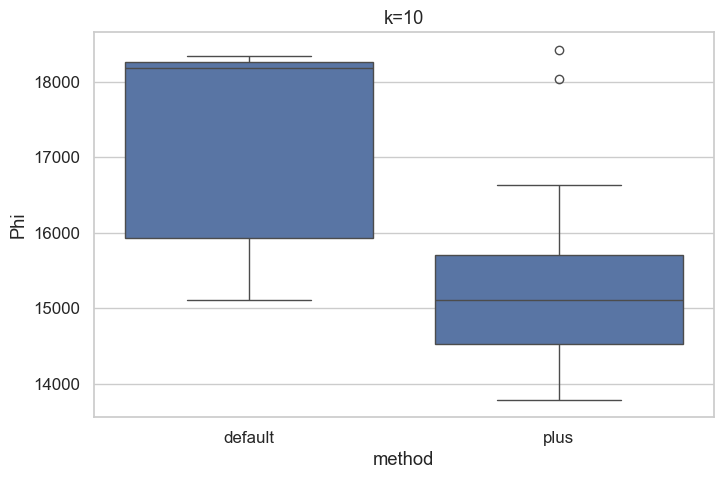

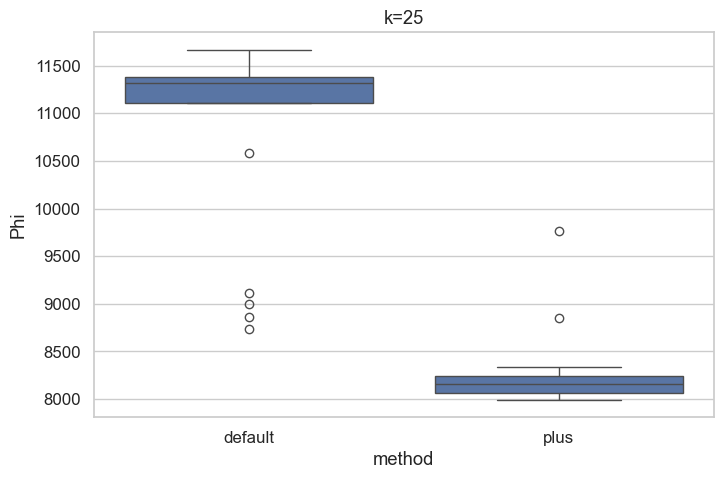

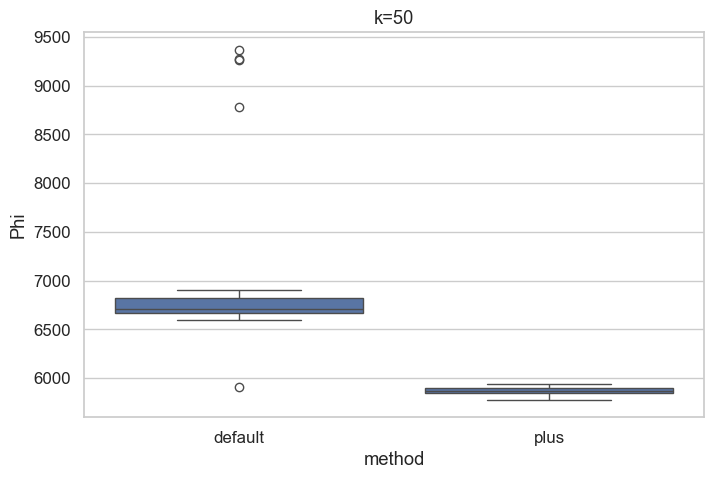

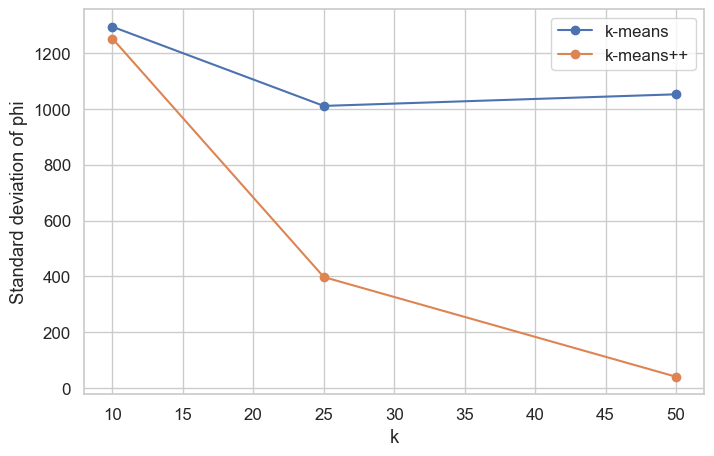

In [246]:
for k in k_values:
    current_data = results[results["k"] == k]
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=current_data, x="method", y="phi")
    plt.title(f"k={k}")
    plt.ylabel("Phi")
    plt.show()

plt.figure(figsize=(8, 5))
plt.plot(summary["k"], summary["default_std"], marker="o", label="k-means")
plt.plot(summary["k"], summary["plus_std"], marker="o", label="k-means++")
plt.xlabel("k")
plt.ylabel("Standard deviation of phi")
plt.legend()
plt.grid(True)
plt.show()

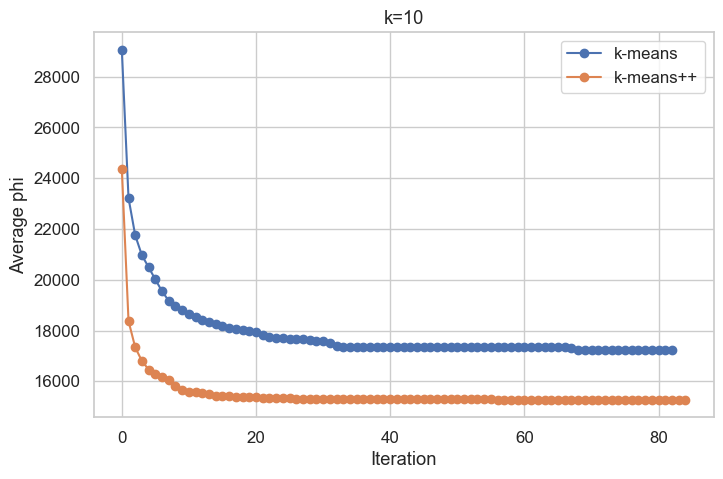

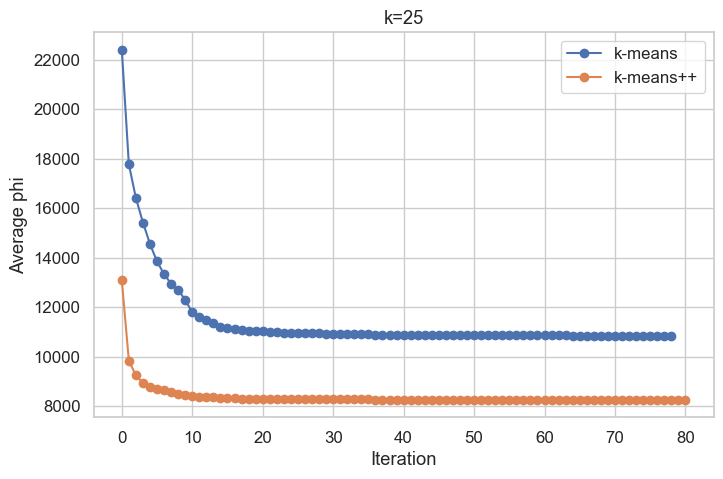

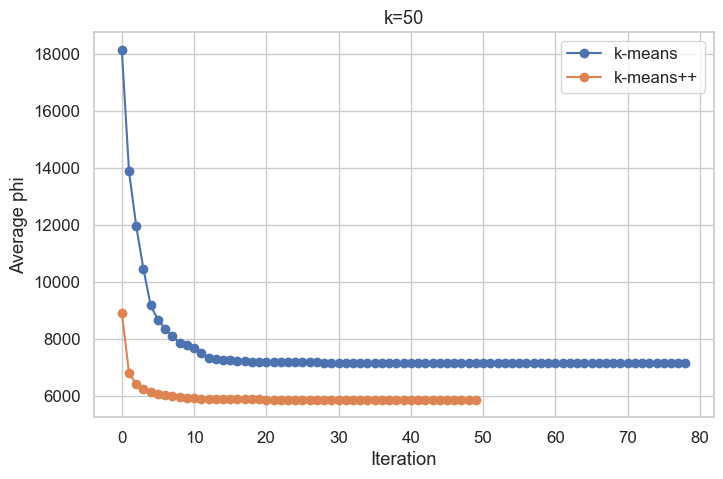

In [247]:
for k in k_values:
    plt.figure(figsize=(8, 5))
    for method, label in [("default", "k-means"), ("plus", "k-means++")]:
        histories = all_histories[k][method]
        max_len = max(len(h) for h in histories)
        padded_histories = []
        for h in histories:
            padded = h.copy()
            while len(padded) < max_len:
                padded.append(padded[-1])
            padded_histories.append(padded)
        padded_histories = np.array(padded_histories)
        average_curve = padded_histories.mean(axis=0)
        plt.plot(average_curve, marker="o", label=label)
        
    plt.title(f"k={k}")
    plt.xlabel("Iteration")
    plt.ylabel("Average phi")
    plt.legend()
    plt.grid(True)
    plt.show()